In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [2]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 03 Evaluate

This notebook loads the trained model, runs sequential inference, computes anomaly scores and reconstruction errors, evaluates early detection, and saves outputs under `results/research_smoke_auto/`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import EvalConfig
from src.evaluate import evaluate_model
from src.utils import read_json

## Sequential Inference And Anomaly Score Calculation

In [4]:
cfg = EvalConfig(
    dataset_dir=RESEARCH_DATASET_DIR,
    model_dir=RESEARCH_MODEL_DIR,
    output_dir=RESEARCH_RESULTS_DIR,
    split="test",
    top_k_features=5,
    use_synthetic_injection=True,
    include_gpt_in_stream=True,
    telegram_enabled=True,
)
eval_summary = evaluate_model(cfg)
eval_summary["evaluation_summary"]

[evaluate] Starting evaluation: split=test, device=cuda, synthetic_injection=True, gpt_stream=True, telegram=True
[evaluate] Loaded split with 39160 windows and 8 features.
[evaluate] Scaling input features and context vectors.
[evaluate] Injecting synthetic anomalies into evaluation windows.
[evaluate] Running model reconstruction.


Reconstructing windows:   0%|                                                                                 …

[evaluate] Computing anomaly scores and threshold decisions.
[evaluate] Simulating realtime stream and optional GPT adjudication.


Streaming inference:   0%|                                                                                    …

[evaluate] Detected 301 anomalous windows at threshold 4.612167. Realtime alerts=301, GPT decisions=301.
[evaluate] Sending Telegram notifications for selected alerts.


Sending Telegram alerts:   0%|                                                                                …

[evaluate] Completed in 5506.7s. F1=0.0000, PR-AUC=0.0001, ROC-AUC=0.5299.


{'threshold': 4.6121673583984375,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 0.00013249263887656865,
 'roc_auc': 0.5298932475227296,
 'num_windows': 39160,
 'num_positive_windows': 4,
 'num_realtime_alerts': 301,
 'num_gpt_decisions': 301,
 'split': 'test',
 'telegram_notifications_sent': 20,
 'telegram_notifications_failed': 0}

In [5]:
predictions = pd.read_csv(cfg.output_dir / "window_level_predictions.csv")
predictions.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,top_k_features,top_k_feature_errors,label,predicted_label,event_id
0,0,unknown_container,unknown_machine,0,test,0.064117,4.612167,-4.548050,"[0.061639465391635895, 0.0018236744217574596, ...","[7, 0, 1, 4, 5, 6, 3, 2]","['disk_io', 'cpu_util', 'mem_util', 'mpki', 'n...","[0.4490198791027069, 0.061639465391635895, 0.0...",0,0,-1
1,1,unknown_container,unknown_machine,1,test,0.080491,4.612167,-4.531676,"[0.05727880448102951, 0.0030133267864584923, 7...","[7, 0, 1, 4, 5, 3, 6, 2]","['disk_io', 'cpu_util', 'mem_util', 'mpki', 'n...","[0.5830671787261963, 0.05727880448102951, 0.00...",0,0,-1
2,2,unknown_container,unknown_machine,2,test,0.064442,4.612167,-4.547726,"[0.04042314738035202, 0.00032455933978781104, ...","[7, 0, 5, 6, 4, 1, 2, 3]","['disk_io', 'cpu_util', 'net_in', 'net_out', '...","[0.4732135236263275, 0.04042314738035202, 0.00...",0,0,-1
3,3,unknown_container,unknown_machine,3,test,0.053010,4.612167,-4.559157,"[0.019661152735352516, 0.0029775628354400396, ...","[7, 0, 1, 6, 3, 4, 5, 2]","['disk_io', 'cpu_util', 'mem_util', 'net_out',...","[0.39997097849845886, 0.019661152735352516, 0....",0,0,-1
4,4,unknown_container,unknown_machine,4,test,0.023750,4.612167,-4.588418,"[0.024262886494398117, 0.005663156975060701, 5...","[7, 0, 1, 6, 5, 3, 4, 2]","['disk_io', 'cpu_util', 'mem_util', 'net_out',...","[0.15653739869594574, 0.024262886494398117, 0....",0,0,-1


## Feature-Wise Reconstruction Error And Top-k Anomalous Features

In [6]:
predictions[
    [
        "window_id",
        "container_id",
        "anomaly_score",
        "top_k_features",
        "top_k_feature_errors",
    ]
].sort_values("anomaly_score", ascending=False).head(10)

,window_id,container_id,anomaly_score,top_k_features,top_k_feature_errors
38710,38710,unknown_container,24.952677,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[183.94964599609375, 14.386698722839355, 0.567..."
37870,37870,unknown_container,24.047836,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[176.5099639892578, 14.479965209960938, 0.5702..."
18607,18607,unknown_container,20.486406,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[144.2533416748047, 16.339296340942383, 2.0979..."
37281,37281,unknown_container,19.621668,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[135.7579803466797, 20.006732940673828, 0.5434..."
19214,19214,unknown_container,19.077480,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[132.72496032714844, 16.615243911743164, 1.920..."
20757,20757,unknown_container,18.441963,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[132.32431030273438, 11.868308067321777, 1.948..."
1778,1778,unknown_container,17.904137,"['mem_gps', 'disk_io', 'cpu_util', 'mpki', 'cpi']","[62.18850326538086, 43.42852020263672, 15.4528..."
20421,20421,unknown_container,17.808876,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[125.85525512695312, 13.15699291229248, 1.7440..."
17749,17749,unknown_container,15.460795,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[103.49669647216797, 16.98398780822754, 1.8710..."
10013,10013,unknown_container,14.731016,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[112.31407928466797, 3.3403143882751465, 0.828..."


## Precision, Recall, F1, PR-AUC, And ROC-AUC

In [7]:
evaluation_summary = read_json(cfg.output_dir / "evaluation_summary.json")
evaluation_summary

{'threshold': 4.6121673583984375,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 0.00013249263887656865,
 'roc_auc': 0.5298932475227296,
 'num_windows': 39160,
 'num_positive_windows': 4,
 'num_realtime_alerts': 301,
 'num_gpt_decisions': 301,
 'split': 'test',
 'telegram_notifications_sent': 20,
 'telegram_notifications_failed': 0}

## Strict And Relaxed Early Detection Evaluation

In [8]:
event_metrics = read_json(cfg.output_dir / "event_metrics.json")
event_metrics

{'num_events': 1,
 'strict_detection_rate': 0.0,
 'relaxed_detection_rate': 0.0,
 'mean_detection_delay': None}

## Streaming-Style Inference Flow

In [9]:
realtime_stream = pd.read_csv(cfg.output_dir / "realtime_stream_predictions.csv")
realtime_stream.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,...,predicted_label,event_id,realtime_step,alert_ready,gpt_triggered,gpt_label,gpt_severity,gpt_recommended_action,gpt_explanation,compact_anomaly_summary
0,0,unknown_container,unknown_machine,0,test,0.064117,4.612167,-4.548050,"[0.061639465391635895, 0.0018236744217574596, ...","[7, 0, 1, 4, 5, 6, 3, 2]",...,0,-1,0,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 0, ""container_id"": ""unknown_cont..."
1,1,unknown_container,unknown_machine,1,test,0.080491,4.612167,-4.531676,"[0.05727880448102951, 0.0030133267864584923, 7...","[7, 0, 1, 4, 5, 3, 6, 2]",...,0,-1,1,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 1, ""container_id"": ""unknown_cont..."
2,2,unknown_container,unknown_machine,2,test,0.064442,4.612167,-4.547726,"[0.04042314738035202, 0.00032455933978781104, ...","[7, 0, 5, 6, 4, 1, 2, 3]",...,0,-1,2,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 2, ""container_id"": ""unknown_cont..."
3,3,unknown_container,unknown_machine,3,test,0.053010,4.612167,-4.559157,"[0.019661152735352516, 0.0029775628354400396, ...","[7, 0, 1, 6, 3, 4, 5, 2]",...,0,-1,3,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 3, ""container_id"": ""unknown_cont..."
4,4,unknown_container,unknown_machine,4,test,0.023750,4.612167,-4.588418,"[0.024262886494398117, 0.005663156975060701, 5...","[7, 0, 1, 6, 5, 3, 4, 2]",...,0,-1,4,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 4, ""container_id"": ""unknown_cont..."


## Detailed Evaluation Analysis And Visualizations

The cells below are analysis-only inspection helpers built on top of the exported evaluation outputs. If a comparison signal is not present in the saved outputs, the notebook uses a clearly labeled proxy or skips the plot with a short note.

In [10]:
# This setup cell prepares notebook-only analysis views, save paths, and safe helper functions.
import ast
import json
from pathlib import Path

import numpy as np
from IPython.display import display

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "semibold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 10,
})

PALETTE = {
    "feature": "#111111",
    "score": "#2b8a68",
    "threshold": "#b23a48",
    "dynamic": "#3f6db5",
    "candidate": "#d95f76",
    "marker": "#6f42c1",
    "grid": "#d9e1ea",
    "normal": "#9aa5b1",
}

figure_results_dir = RESULTS_DIR / "figures"
analysis_results_dir = RESULTS_DIR / "analysis"
figure_results_dir.mkdir(parents=True, exist_ok=True)
analysis_results_dir.mkdir(parents=True, exist_ok=True)

saved_figures = {}
saved_tables = {}

def note(message):
    print(message)

def save_table(frame, filename, index=False):
    path = analysis_results_dir / filename
    frame.to_csv(path, index=index)
    saved_tables[filename] = str(path)
    return path

def save_figure(fig, filename):
    path = figure_results_dir / filename
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    saved_figures[filename] = str(path)
    return path

def style_axis(ax):
    ax.grid(True, color=PALETTE["grid"], linewidth=0.8, alpha=0.85)
    ax.set_axisbelow(True)

def dedupe_legend(ax, location="best"):
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    seen = {}
    for handle, label in zip(handles, labels):
        if label not in seen:
            seen[label] = handle
    ax.legend(seen.values(), seen.keys(), loc=location)

def parse_literal_list(value):
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except Exception:
            return []
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        return list(value)
    return []

def bool_from_series(series):
    if series is None:
        return pd.Series(False, index=[])
    if series.dtype == bool:
        return series.fillna(False)
    lowered = series.astype(str).str.strip().str.lower()
    if lowered.isin(["true", "false"]).all():
        return lowered.eq("true")
    return pd.to_numeric(series, errors="coerce").fillna(0).astype(float).gt(0)

def contiguous_regions(x_values, mask):
    regions = []
    start = None
    for idx, is_positive in enumerate(mask):
        if is_positive and start is None:
            start = idx
        elif (not is_positive) and start is not None:
            regions.append((x_values[start], x_values[idx - 1]))
            start = None
    if start is not None and len(x_values):
        regions.append((x_values[start], x_values[-1]))
    return regions

def add_region_overlay(ax, frame, x_col, mask_col, label, color, alpha=0.14):
    if mask_col not in frame.columns:
        return
    mask = frame[mask_col].fillna(False).astype(bool).to_numpy()
    if not mask.any():
        return
    x_values = frame[x_col].to_numpy()
    for start, end in contiguous_regions(x_values, mask):
        ax.axvspan(start, end, color=color, alpha=alpha, lw=0)
    ax.plot([], [], color=color, lw=8, alpha=max(alpha, 0.18), label=label)

def safe_text_axis(ax, title, message):
    ax.set_title(title)
    ax.text(0.5, 0.5, message, ha="center", va="center", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

viz_predictions = predictions.copy()
numeric_columns = [
    "window_id",
    "end_time",
    "realtime_step",
    "anomaly_score",
    "threshold",
    "score_over_threshold",
    "label",
    "predicted_label",
    "event_id",
]
for column in numeric_columns:
    if column in viz_predictions.columns:
        viz_predictions[column] = pd.to_numeric(viz_predictions[column], errors="coerce")

viz_predictions = viz_predictions.sort_values("window_id").reset_index(drop=True)
viz_predictions["row_position"] = np.arange(len(viz_predictions))

dataset_meta_path = cfg.dataset_dir / "dataset_meta.json"
dataset_meta = json.loads(dataset_meta_path.read_text(encoding="utf-8")) if dataset_meta_path.exists() else {}
feature_columns = dataset_meta.get("feature_columns", [])
selected_feature_names = [
    feature_name
    for feature_name in ["cpu_util", "mem_util", "net_in", "net_out", "disk_io"]
    if feature_name in feature_columns
]

window_meta_path = cfg.dataset_dir / "window_metadata_test.csv"
window_meta_test = pd.read_csv(window_meta_path) if window_meta_path.exists() else pd.DataFrame()
if not window_meta_test.empty:
    for column in ["window_id", "end_time"]:
        if column in window_meta_test.columns:
            window_meta_test[column] = pd.to_numeric(window_meta_test[column], errors="coerce")
    merge_columns = [column for column in ["window_id", "entity_id", "container_id", "machine_id", "end_time"] if column in window_meta_test.columns]
    meta_merge = window_meta_test[merge_columns].rename(
        columns={
            "container_id": "meta_container_id",
            "machine_id": "meta_machine_id",
            "end_time": "meta_end_time",
        }
    )
    viz_predictions = viz_predictions.merge(meta_merge, on="window_id", how="left")
else:
    note("window_metadata_test.csv was not found. Entity-aware local plots will fall back to window ordering.")

if "window_id" in realtime_stream.columns:
    realtime_merge = realtime_stream.copy()
    for column in ["window_id", "realtime_step"]:
        if column in realtime_merge.columns:
            realtime_merge[column] = pd.to_numeric(realtime_merge[column], errors="coerce")
    for column in ["alert_ready", "gpt_triggered"]:
        if column in realtime_merge.columns:
            realtime_merge[column] = bool_from_series(realtime_merge[column])
    keep_columns = [column for column in ["window_id", "realtime_step", "alert_ready", "gpt_triggered"] if column in realtime_merge.columns]
    realtime_merge = realtime_merge[keep_columns].drop_duplicates(subset=["window_id"])
    viz_predictions = viz_predictions.merge(realtime_merge, on="window_id", how="left", suffixes=("", "_rt"))

threshold_value = None
if "threshold" in viz_predictions.columns and viz_predictions["threshold"].notna().any():
    threshold_value = float(viz_predictions["threshold"].dropna().iloc[0])
elif isinstance(evaluation_summary, dict) and evaluation_summary.get("threshold") is not None:
    threshold_value = float(evaluation_summary["threshold"])

viz_predictions["fixed_threshold"] = threshold_value if threshold_value is not None else np.nan
viz_predictions["final_threshold"] = (
    viz_predictions["threshold"].fillna(threshold_value)
    if "threshold" in viz_predictions.columns
    else threshold_value
)

score_series = pd.to_numeric(viz_predictions["anomaly_score"], errors="coerce").fillna(0.0)
rolling_window = 250
rolling_center = score_series.rolling(rolling_window, min_periods=50).median()
rolling_scale = score_series.rolling(rolling_window, min_periods=50).std()
expanding_center = score_series.expanding(min_periods=10).median()
expanding_scale = score_series.expanding(min_periods=10).std().fillna(0.0)
viz_predictions["dynamic_threshold_proxy"] = (
    rolling_center.fillna(expanding_center) + 3.0 * rolling_scale.fillna(expanding_scale)
).fillna(score_series.median())

score_std = float(score_series.std(ddof=0))
viz_predictions["score_z"] = 0.0 if score_std == 0 else (score_series - score_series.mean()) / score_std
viz_predictions["z_score_candidate_flag"] = viz_predictions["score_z"].abs() >= 3.0

if "predicted_label" in viz_predictions.columns:
    viz_predictions["raw_predicted_flag"] = bool_from_series(viz_predictions["predicted_label"])
else:
    viz_predictions["raw_predicted_flag"] = False

if "alert_ready" in viz_predictions.columns:
    viz_predictions["final_combined_candidate_flag"] = bool_from_series(viz_predictions["alert_ready"])
    final_candidate_source = "alert_ready"
else:
    viz_predictions["final_combined_candidate_flag"] = viz_predictions["raw_predicted_flag"]
    final_candidate_source = "predicted_label"

viz_predictions["dynamic_threshold_candidate_flag"] = score_series > viz_predictions["dynamic_threshold_proxy"]

feature_error_matrix = None
if "feature_error_vector" in viz_predictions.columns:
    parsed_feature_errors = viz_predictions["feature_error_vector"].apply(parse_literal_list)
    valid_lengths = parsed_feature_errors.apply(len)
    if valid_lengths.gt(0).all() and valid_lengths.nunique() == 1:
        feature_error_matrix = np.vstack(parsed_feature_errors.apply(lambda values: np.asarray(values, dtype=float)).to_numpy())
        viz_predictions["top_feature_error"] = np.nanmax(feature_error_matrix, axis=1)
    else:
        viz_predictions["top_feature_error"] = np.nan
        note("feature_error_vector was not consistently shaped. Feature-error matrix plots will be skipped.")
else:
    viz_predictions["top_feature_error"] = np.nan

top_feature_error_std = float(viz_predictions["top_feature_error"].fillna(0.0).std(ddof=0))
viz_predictions["feature_error_z"] = (
    0.0
    if top_feature_error_std == 0
    else (viz_predictions["top_feature_error"].fillna(0.0) - viz_predictions["top_feature_error"].fillna(0.0).mean()) / top_feature_error_std
)
viz_predictions["feature_shift_candidate_flag"] = viz_predictions["feature_error_z"].abs() >= 3.0

if "label" in viz_predictions.columns and bool_from_series(viz_predictions["label"]).any():
    viz_predictions["candidate_region_flag"] = bool_from_series(viz_predictions["label"])
    candidate_region_label = "True anomaly region"
else:
    viz_predictions["candidate_region_flag"] = viz_predictions["final_combined_candidate_flag"]
    candidate_region_label = "Candidate region"

viz_predictions["display_time"] = np.where(
    viz_predictions.get("meta_end_time", pd.Series(np.nan, index=viz_predictions.index)).notna(),
    viz_predictions.get("meta_end_time", pd.Series(np.nan, index=viz_predictions.index)),
    viz_predictions.get("end_time", viz_predictions["window_id"]),
)

viz_predictions["top_k_features_list"] = (
    viz_predictions["top_k_features"].apply(parse_literal_list)
    if "top_k_features" in viz_predictions.columns
    else [[] for _ in range(len(viz_predictions))]
)
viz_predictions["top_k_feature_errors_list"] = (
    viz_predictions["top_k_feature_errors"].apply(parse_literal_list)
    if "top_k_feature_errors" in viz_predictions.columns
    else [[] for _ in range(len(viz_predictions))]
)

x_test_path = cfg.dataset_dir / "X_test.npy"
x_test = np.load(x_test_path, mmap_mode="r") if x_test_path.exists() else None

if (cfg.output_dir / "top_anomalous_windows.csv").exists():
    top_windows = pd.read_csv(cfg.output_dir / "top_anomalous_windows.csv")
    for column in numeric_columns:
        if column in top_windows.columns:
            top_windows[column] = pd.to_numeric(top_windows[column], errors="coerce")
else:
    top_windows = viz_predictions.sort_values("anomaly_score", ascending=False).copy()

top_windows = top_windows.merge(
    viz_predictions[["window_id", "final_combined_candidate_flag", "raw_predicted_flag", "display_time"]],
    on="window_id",
    how="left",
).sort_values("anomaly_score", ascending=False).reset_index(drop=True)

analysis_notes = pd.DataFrame(
    [
        {"signal": "fixed_threshold", "source": "exported evaluation output", "kind": "existing"},
        {"signal": "final_threshold", "source": "exported evaluation output", "kind": "existing"},
        {
            "signal": "dynamic_threshold_proxy",
            "source": "rolling median + 3 * rolling std on anomaly_score",
            "kind": "analysis proxy",
        },
        {"signal": "raw_predicted_flag", "source": "predicted_label", "kind": "existing"},
        {"signal": "final_combined_candidate_flag", "source": final_candidate_source, "kind": "existing"},
        {"signal": "z_score_candidate_flag", "source": "global anomaly_score z-score >= 3", "kind": "analysis proxy"},
        {
            "signal": "feature_shift_candidate_flag",
            "source": "top_feature_error z-score >= 3",
            "kind": "analysis proxy",
        },
    ]
)
save_table(analysis_notes, "analysis_signal_notes.csv")

note(f"Figures will be saved to: {figure_results_dir}")
note(f"Analysis tables will be saved to: {analysis_results_dir}")

Figures will be saved to: C:\Users\kaspe\Desktop\Project\project\results\figures
Analysis tables will be saved to: C:\Users\kaspe\Desktop\Project\project\results\analysis


In [11]:
# This cell prints the basic evaluation overview, threshold values, top anomalous windows, and compact summary tables.
window_shape = tuple(int(value) for value in x_test.shape) if x_test is not None else "X_test.npy not found"
num_windows = int(len(viz_predictions))
num_final_candidates = int(viz_predictions["final_combined_candidate_flag"].sum())
num_raw_predicted = int(viz_predictions["raw_predicted_flag"].sum())
num_dynamic_candidates = int(viz_predictions["dynamic_threshold_candidate_flag"].sum())
num_true_regions = int(bool_from_series(viz_predictions["label"]).sum()) if "label" in viz_predictions.columns else np.nan

overview_df = pd.DataFrame(
    [
        {"metric": "dataset_window_shape", "value": str(window_shape)},
        {"metric": "num_windows", "value": num_windows},
        {"metric": "num_raw_predicted", "value": num_raw_predicted},
        {"metric": "num_final_candidates", "value": num_final_candidates},
        {"metric": "num_dynamic_threshold_candidates", "value": num_dynamic_candidates},
        {"metric": "num_true_label_windows", "value": num_true_regions},
        {"metric": "fixed_threshold", "value": threshold_value},
        {"metric": "final_threshold", "value": threshold_value},
        {"metric": "dynamic_threshold_proxy_mean", "value": float(viz_predictions["dynamic_threshold_proxy"].mean())},
    ]
)

summary_table = pd.DataFrame([
    {
        **(evaluation_summary if isinstance(evaluation_summary, dict) else {}),
        **({f"event_{key}": value for key, value in event_metrics.items()} if isinstance(event_metrics, dict) else {}),
    }
])

top_n = 15
top_columns = [
    column
    for column in [
        "window_id",
        "display_time",
        "entity_id",
        "container_id",
        "anomaly_score",
        "threshold",
        "score_over_threshold",
        "top_k_features",
        "top_k_feature_errors",
        "final_combined_candidate_flag",
    ]
    if column in top_windows.columns
]
top_anomalies_table = top_windows[top_columns].head(top_n).copy()

save_table(overview_df, "evaluation_overview_metrics.csv")
save_table(summary_table, "evaluation_summary_compact.csv")
save_table(top_anomalies_table, "top_anomalous_windows_detailed.csv")

display(overview_df)
display(summary_table)
display(top_anomalies_table)

,metric,value
0,dataset_window_shape,"(39160, 30, 8)"
1,num_windows,39160
2,num_raw_predicted,301
3,num_final_candidates,301
4,num_dynamic_threshold_candidates,690
5,num_true_label_windows,4
6,fixed_threshold,4.612167
7,final_threshold,4.612167
8,dynamic_threshold_proxy_mean,2.681921


,threshold,precision,recall,f1,pr_auc,roc_auc,num_windows,num_positive_windows,num_realtime_alerts,num_gpt_decisions,split,telegram_notifications_sent,telegram_notifications_failed,event_num_events,event_strict_detection_rate,event_relaxed_detection_rate,event_mean_detection_delay
0,4.612167,0.0,0.0,0.0,0.000132,0.529893,39160,4,301,301,test,20,0,1,0.0,0.0,None


,window_id,display_time,container_id,anomaly_score,threshold,score_over_threshold,top_k_features,top_k_feature_errors,final_combined_candidate_flag
0,38710,776220.0,unknown_container,24.952677,4.612167,20.340509,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[183.94964599609375, 14.386698722839355, 0.567...",True
1,37870,773650.0,unknown_container,24.047836,4.612167,19.435669,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[176.5099639892578, 14.479965209960938, 0.5702...",True
2,18607,710920.0,unknown_container,20.486406,4.612167,15.874239,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[144.2533416748047, 16.339296340942383, 2.0979...",True
3,37281,771860.0,unknown_container,19.621668,4.612167,15.009501,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[135.7579803466797, 20.006732940673828, 0.5434...",True
4,19214,713040.0,unknown_container,19.077480,4.612167,14.465313,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[132.72496032714844, 16.615243911743164, 1.920...",True
5,20757,718500.0,unknown_container,18.441963,4.612167,13.829796,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[132.32431030273438, 11.868308067321777, 1.948...",True
6,1778,649400.0,unknown_container,17.904137,4.612167,13.291969,"['mem_gps', 'disk_io', 'cpu_util', 'mpki', 'cpi']","[62.18850326538086, 43.42852020263672, 15.4528...",True
7,20421,717170.0,unknown_container,17.808876,4.612167,13.196709,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[125.85525512695312, 13.15699291229248, 1.7440...",True
8,17749,707820.0,unknown_container,15.460795,4.612167,10.848628,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[103.49669647216797, 16.98398780822754, 1.8710...",True
9,10013,680600.0,unknown_container,14.731016,4.612167,10.118849,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[112.31407928466797, 3.3403143882751465, 0.828...",True


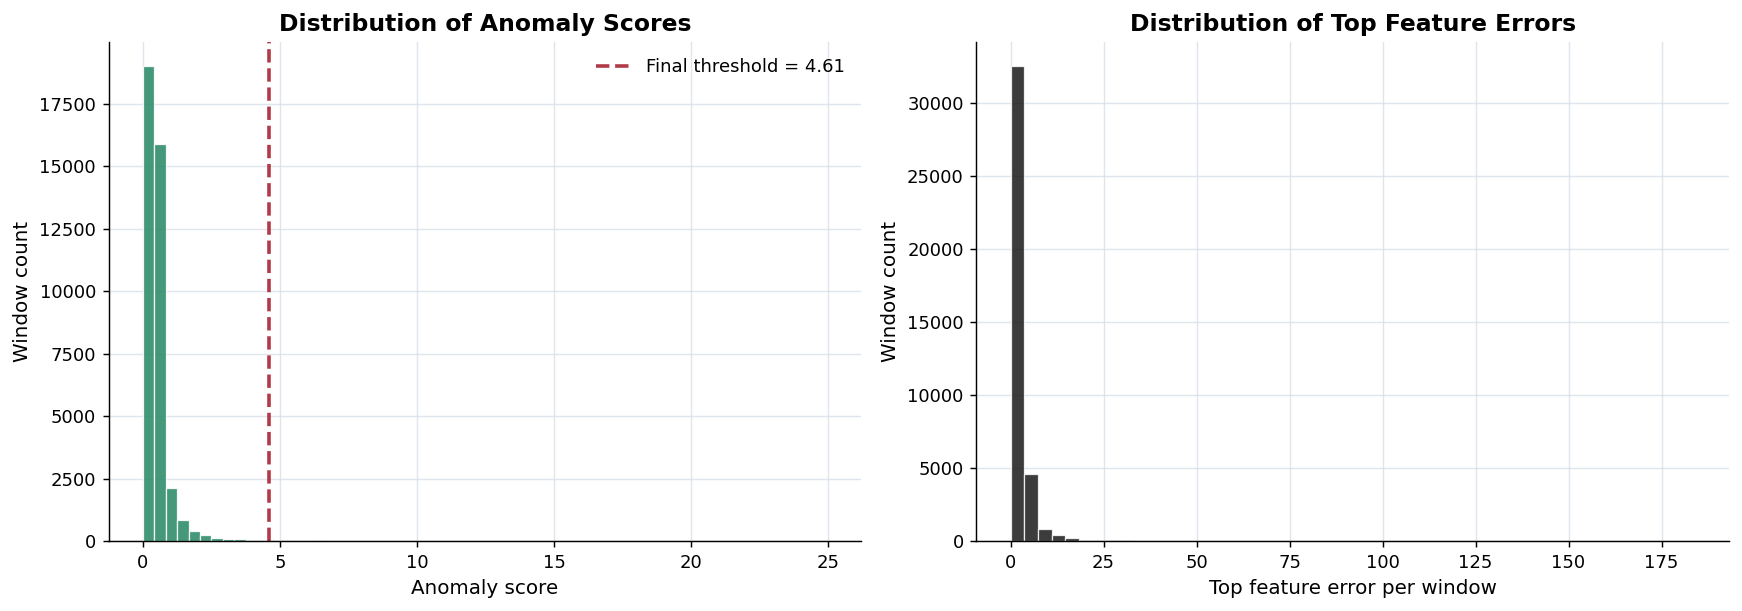

WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_distribution_histograms.png')

In [12]:
# This cell compares the main score distribution against top feature-error distribution and marks the final threshold.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
score_values = viz_predictions["anomaly_score"].dropna().to_numpy()
bin_count = int(np.clip(np.sqrt(max(score_values.size, 1)), 25, 60))

axes[0].hist(
    score_values,
    bins=bin_count,
    color=PALETTE["score"],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.7,
)
if threshold_value is not None:
    axes[0].axvline(
        threshold_value,
        color=PALETTE["threshold"],
        linestyle="--",
        linewidth=2.0,
        label=f"Final threshold = {threshold_value:.2f}",
    )
axes[0].set_title("Distribution of Anomaly Scores")
axes[0].set_xlabel("Anomaly score")
axes[0].set_ylabel("Window count")
style_axis(axes[0])
dedupe_legend(axes[0], location="upper right")

if viz_predictions["top_feature_error"].notna().any():
    feature_error_values = viz_predictions["top_feature_error"].dropna().to_numpy()
    feature_bins = int(np.clip(np.sqrt(max(feature_error_values.size, 1)), 20, 50))
    axes[1].hist(
        feature_error_values,
        bins=feature_bins,
        color=PALETTE["feature"],
        alpha=0.82,
        edgecolor="white",
        linewidth=0.7,
    )
    axes[1].set_title("Distribution of Top Feature Errors")
    axes[1].set_xlabel("Top feature error per window")
    axes[1].set_ylabel("Window count")
    style_axis(axes[1])
else:
    safe_text_axis(axes[1], "Distribution of Top Feature Errors", "top_feature_error is unavailable for this run.")

distribution_path = save_figure(fig, "eval_distribution_histograms.png")
plt.show()

distribution_path

C:\Users\kaspe\AppData\Local\Temp\ipykernel_23720\862162364.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(candidate_groups, patch_artist=True, labels=["normal", "candidate"], boxprops={"facecolor": "#cfe8dd"})


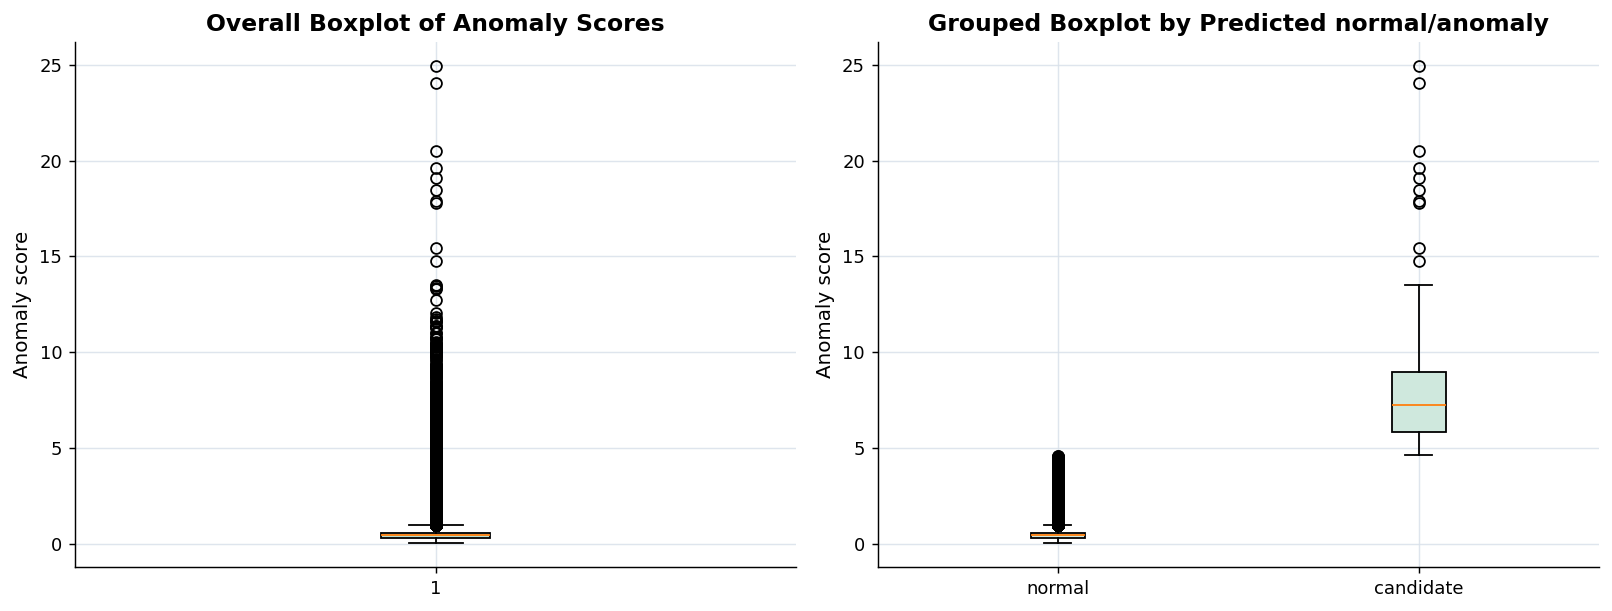

WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_score_boxplots.png')

In [13]:
# This cell shows anomaly-score boxplots overall and grouped by predicted/final candidate status when available.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

axes[0].boxplot(viz_predictions["anomaly_score"].dropna().to_numpy(), vert=True, patch_artist=True, boxprops={"facecolor": "#b8decf"})
axes[0].set_title("Overall Boxplot of Anomaly Scores")
axes[0].set_ylabel("Anomaly score")
style_axis(axes[0])

candidate_groups = []
for flag_name, label in [
    ("raw_predicted_flag", "Predicted normal/anomaly"),
    ("final_combined_candidate_flag", "Final candidate normal/anomaly"),
]:
    if flag_name in viz_predictions.columns:
        false_group = viz_predictions.loc[~viz_predictions[flag_name], "anomaly_score"].dropna().to_numpy()
        true_group = viz_predictions.loc[viz_predictions[flag_name], "anomaly_score"].dropna().to_numpy()
        if false_group.size and true_group.size:
            candidate_groups = [false_group, true_group]
            axes[1].boxplot(candidate_groups, patch_artist=True, labels=["normal", "candidate"], boxprops={"facecolor": "#cfe8dd"})
            axes[1].set_title(f"Grouped Boxplot by {label}")
            axes[1].set_ylabel("Anomaly score")
            style_axis(axes[1])
            break

if not candidate_groups:
    safe_text_axis(axes[1], "Grouped Candidate Boxplot", "Grouped candidate comparison was skipped because one or more groups are empty.")

boxplot_path = save_figure(fig, "eval_score_boxplots.png")
plt.show()

boxplot_path

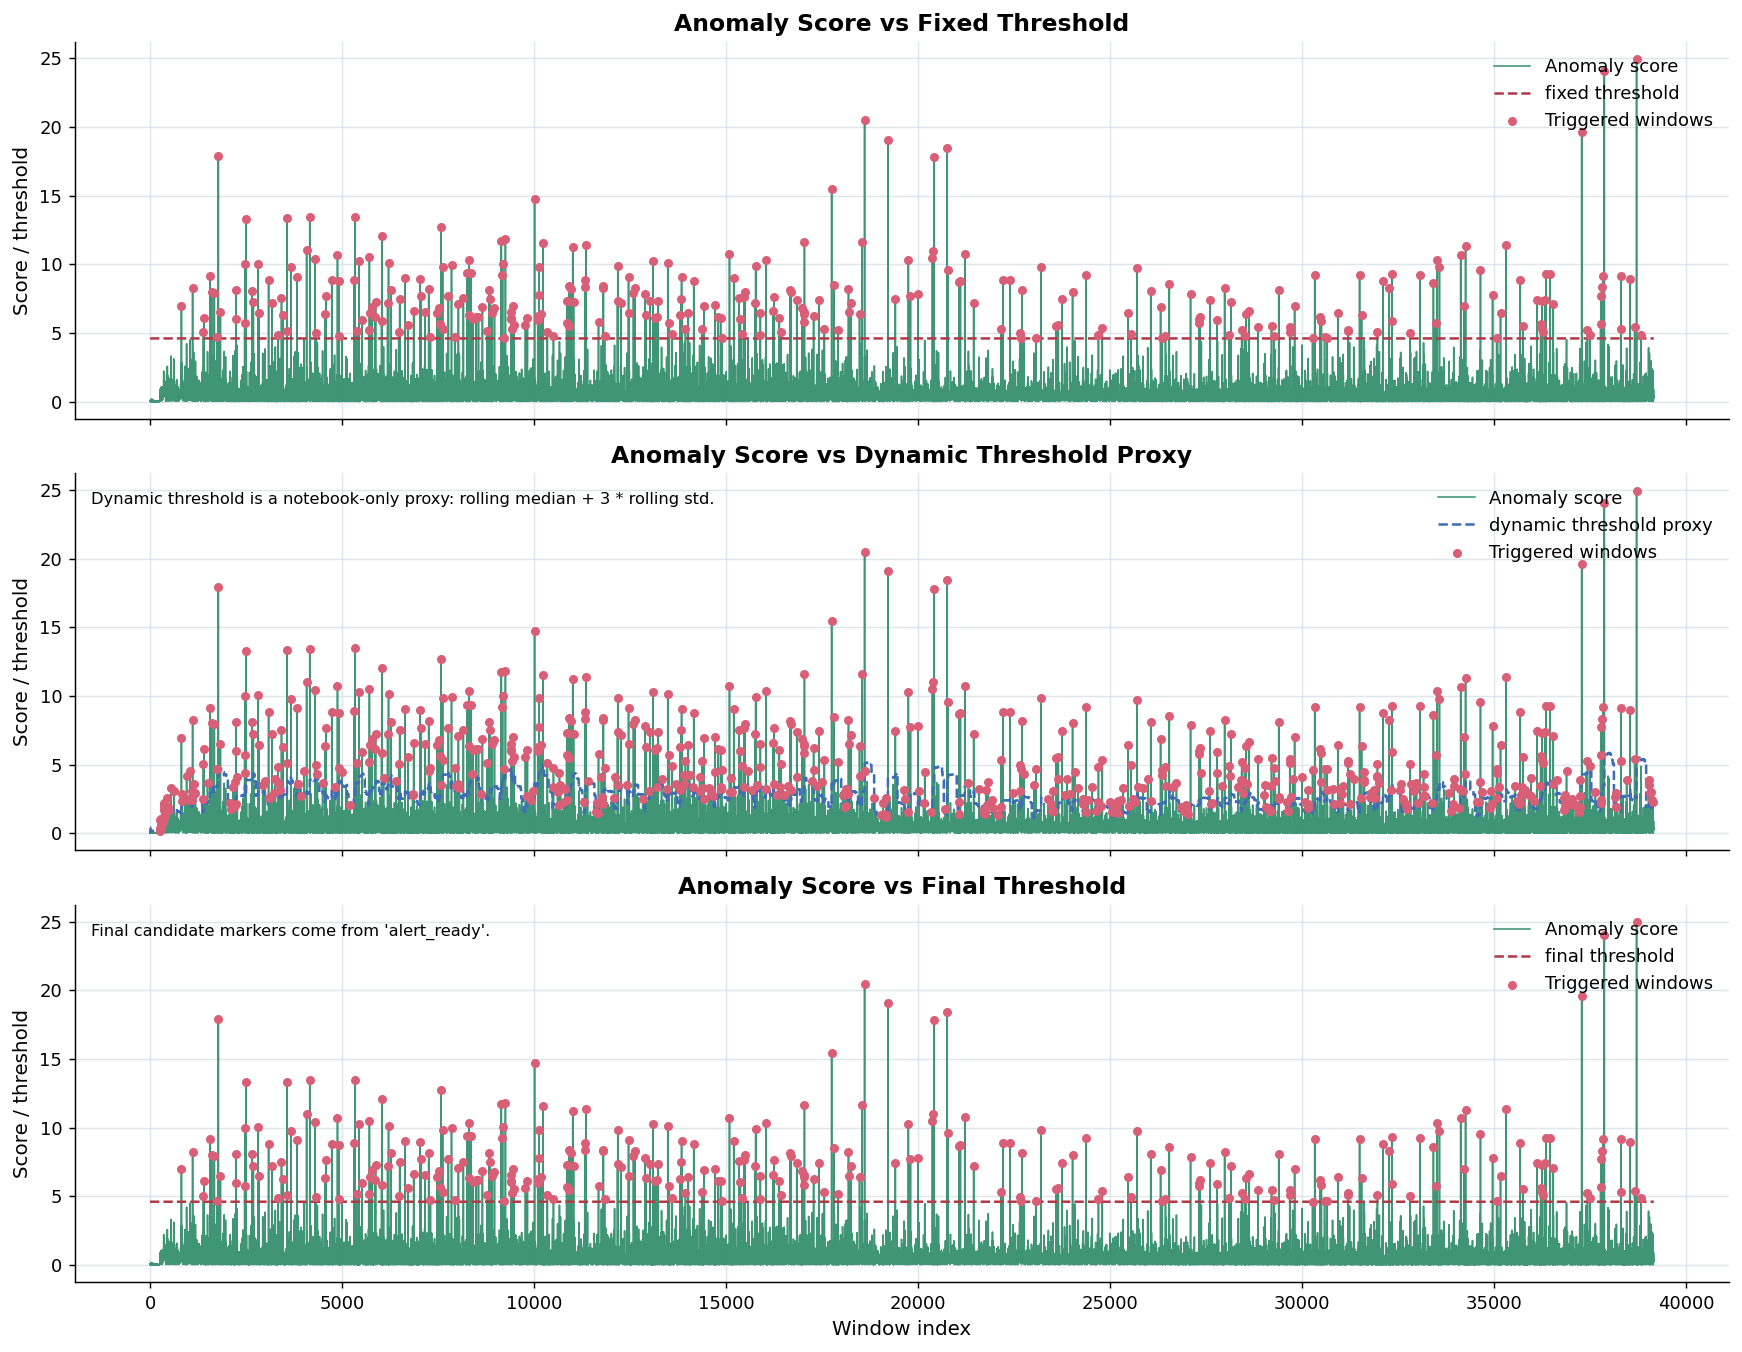

WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_threshold_comparison.png')

In [14]:
# This cell compares anomaly scores against exported fixed/final thresholds and an analysis-only dynamic-threshold proxy.
fig, axes = plt.subplots(3, 1, figsize=(13.5, 10.5), sharex=True)
x_values = viz_predictions["window_id"].to_numpy()
score_values = viz_predictions["anomaly_score"].to_numpy()

comparison_specs = [
    ("fixed_threshold", "Anomaly Score vs Fixed Threshold", score_values >= viz_predictions["fixed_threshold"].fillna(np.inf).to_numpy(), PALETTE["threshold"]),
    (
        "dynamic_threshold_proxy",
        "Anomaly Score vs Dynamic Threshold Proxy",
        viz_predictions["dynamic_threshold_candidate_flag"].to_numpy(),
        PALETTE["dynamic"],
    ),
    (
        "final_threshold",
        "Anomaly Score vs Final Threshold",
        viz_predictions["final_combined_candidate_flag"].to_numpy(),
        PALETTE["threshold"],
    ),
]

for ax, (threshold_col, title, trigger_mask, threshold_color) in zip(axes, comparison_specs):
    ax.plot(x_values, score_values, color=PALETTE["score"], linewidth=0.9, alpha=0.9, label="Anomaly score")
    if threshold_col in viz_predictions.columns and pd.Series(viz_predictions[threshold_col]).notna().any():
        ax.plot(
            x_values,
            viz_predictions[threshold_col].to_numpy(),
            color=threshold_color,
            linestyle="--",
            linewidth=1.4,
            label=threshold_col.replace("_", " "),
        )
    ax.scatter(
        x_values[trigger_mask],
        score_values[trigger_mask],
        color=PALETTE["candidate"],
        s=16,
        zorder=4,
        label="Triggered windows",
    )
    ax.set_title(title)
    ax.set_ylabel("Score / threshold")
    style_axis(ax)
    dedupe_legend(ax, location="upper right")

axes[1].text(
    0.01,
    0.95,
    "Dynamic threshold is a notebook-only proxy: rolling median + 3 * rolling std.",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=9,
)
axes[2].text(
    0.01,
    0.95,
    f"Final candidate markers come from '{final_candidate_source}'.",
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=9,
)
axes[-1].set_xlabel("Window index")

threshold_path = save_figure(fig, "eval_threshold_comparison.png")
plt.show()

threshold_path

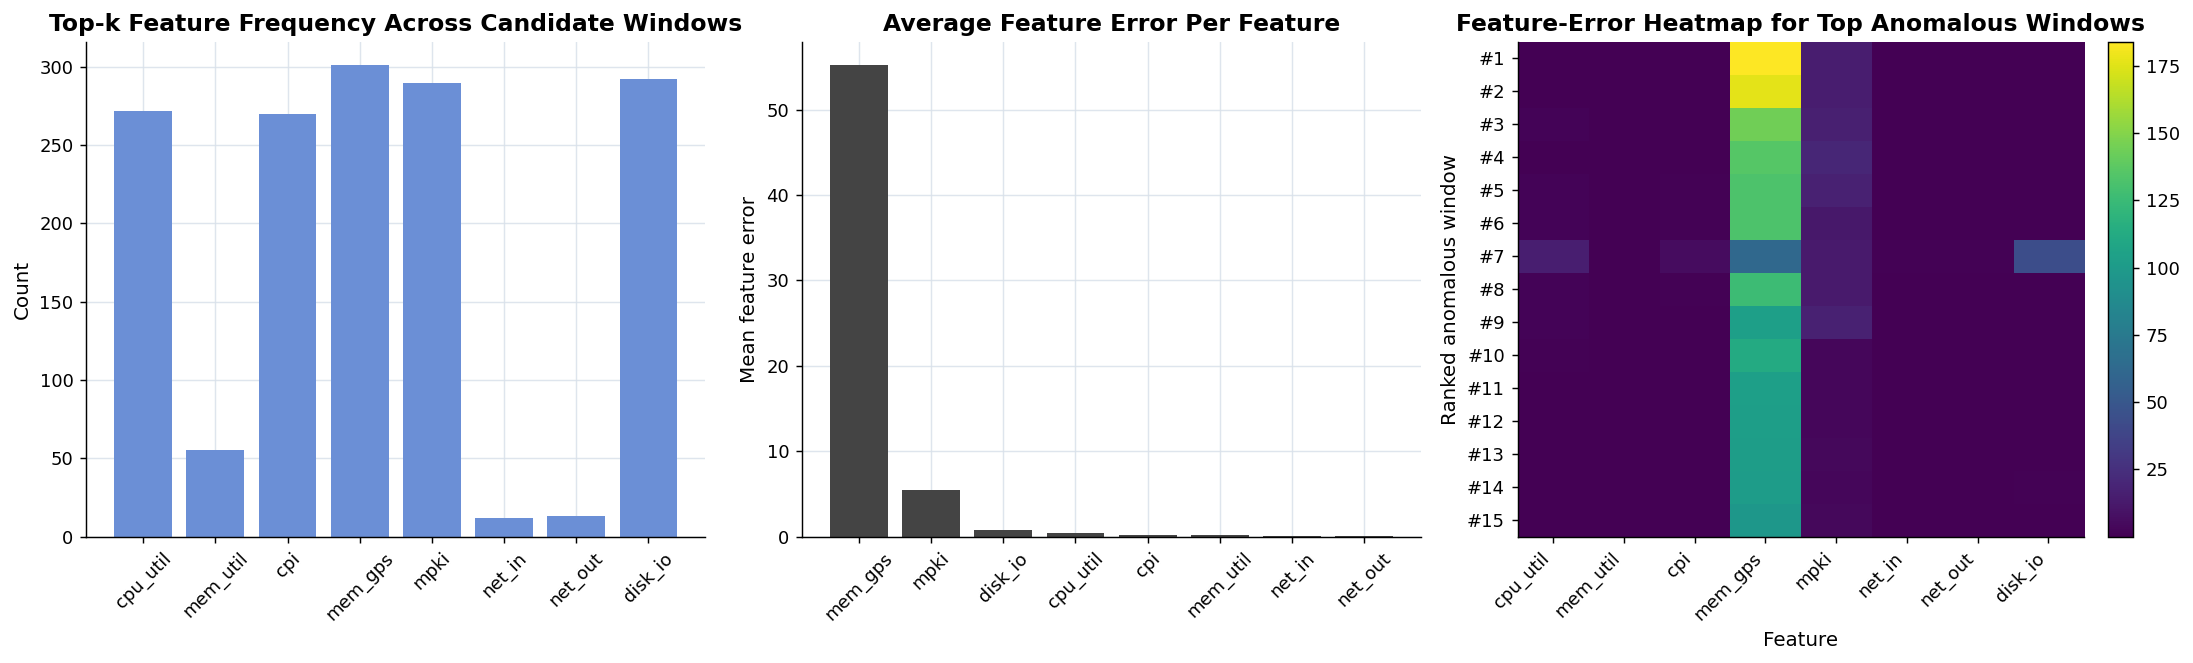

WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_feature_importance_comparison.png')

In [15]:
# This cell compares which features contribute most to anomalous windows using frequency, mean error, and a heatmap.
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

candidate_subset = viz_predictions[viz_predictions["final_combined_candidate_flag"]].copy()
if candidate_subset.empty:
    candidate_subset = viz_predictions.sort_values("anomaly_score", ascending=False).head(50).copy()
    note("No final candidates were available. Feature summaries fall back to the top 50 anomaly-score windows.")

feature_frequency = pd.Series(dtype=float)
if "top_k_features_list" in candidate_subset.columns:
    exploded_features = candidate_subset["top_k_features_list"].explode()
    if exploded_features.notna().any():
        feature_frequency = exploded_features.value_counts().reindex(feature_columns, fill_value=0)

if not feature_frequency.empty:
    axes[0].bar(feature_frequency.index.astype(str), feature_frequency.values, color="#6b8fd6")
    axes[0].set_title("Top-k Feature Frequency Across Candidate Windows")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)
    style_axis(axes[0])
else:
    safe_text_axis(axes[0], "Top-k Feature Frequency Across Candidate Windows", "top_k_features is unavailable for this run.")

feature_mean_error_df = pd.DataFrame()
if feature_error_matrix is not None and feature_columns:
    candidate_rows = candidate_subset["row_position"].astype(int).to_numpy()
    candidate_feature_errors = feature_error_matrix[candidate_rows]
    feature_mean_error_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "mean_feature_error": np.nanmean(candidate_feature_errors, axis=0),
        }
    ).sort_values("mean_feature_error", ascending=False)
    axes[1].bar(feature_mean_error_df["feature"], feature_mean_error_df["mean_feature_error"], color="#444444")
    axes[1].set_title("Average Feature Error Per Feature")
    axes[1].set_ylabel("Mean feature error")
    axes[1].tick_params(axis="x", rotation=45)
    style_axis(axes[1])
else:
    safe_text_axis(axes[1], "Average Feature Error Per Feature", "feature_error_vector is unavailable for this run.")

if feature_error_matrix is not None and feature_columns:
    heatmap_windows = viz_predictions.sort_values("anomaly_score", ascending=False).head(15).copy()
    heatmap_matrix = feature_error_matrix[heatmap_windows["row_position"].astype(int).to_numpy()]
    im = axes[2].imshow(heatmap_matrix, aspect="auto", cmap="viridis")
    axes[2].set_title("Feature-Error Heatmap for Top Anomalous Windows")
    axes[2].set_xlabel("Feature")
    axes[2].set_ylabel("Ranked anomalous window")
    axes[2].set_xticks(np.arange(len(feature_columns)))
    axes[2].set_xticklabels(feature_columns, rotation=45, ha="right")
    axes[2].set_yticks(np.arange(len(heatmap_windows)))
    axes[2].set_yticklabels([f"#{rank}" for rank in range(1, len(heatmap_windows) + 1)])
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
else:
    safe_text_axis(axes[2], "Feature-Error Heatmap for Top Anomalous Windows", "Heatmap was skipped because feature_error_vector is unavailable.")

if not feature_mean_error_df.empty:
    save_table(feature_mean_error_df, "feature_mean_error_summary.csv")
if not feature_frequency.empty:
    save_table(feature_frequency.rename_axis("feature").reset_index(name="candidate_frequency"), "feature_frequency_summary.csv")

feature_importance_path = save_figure(fig, "eval_feature_importance_comparison.png")
plt.show()

feature_importance_path

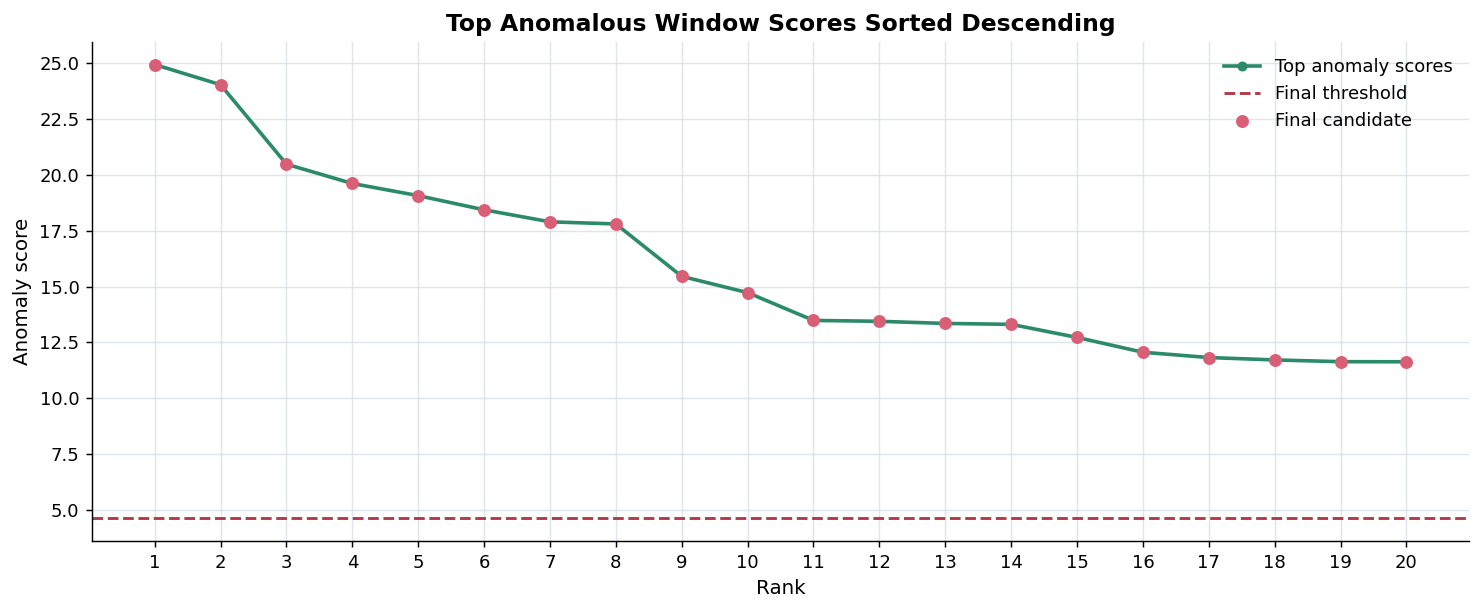

,rank,window_id,display_time,anomaly_score,threshold,score_over_threshold,top_k_features,top_k_feature_errors,raw_predicted_flag,final_combined_candidate_flag
0,1,38710,776220.0,24.952677,4.612167,20.340509,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[183.94964599609375, 14.386698722839355, 0.567...",True,True
1,2,37870,773650.0,24.047836,4.612167,19.435669,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[176.5099639892578, 14.479965209960938, 0.5702...",True,True
2,3,18607,710920.0,20.486406,4.612167,15.874239,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[144.2533416748047, 16.339296340942383, 2.0979...",True,True
3,4,37281,771860.0,19.621668,4.612167,15.009501,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[135.7579803466797, 20.006732940673828, 0.5434...",True,True
4,5,19214,713040.0,19.077480,4.612167,14.465313,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[132.72496032714844, 16.615243911743164, 1.920...",True,True
5,6,20757,718500.0,18.441963,4.612167,13.829796,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[132.32431030273438, 11.868308067321777, 1.948...",True,True
6,7,1778,649400.0,17.904137,4.612167,13.291969,"['mem_gps', 'disk_io', 'cpu_util', 'mpki', 'cpi']","[62.18850326538086, 43.42852020263672, 15.4528...",True,True
7,8,20421,717170.0,17.808876,4.612167,13.196709,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[125.85525512695312, 13.15699291229248, 1.7440...",True,True
8,9,17749,707820.0,15.460795,4.612167,10.848628,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[103.49669647216797, 16.98398780822754, 1.8710...",True,True
9,10,10013,680600.0,14.731016,4.612167,10.118849,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[112.31407928466797, 3.3403143882751465, 0.828...",True,True


WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_top_window_ranking.png')

In [16]:
# This cell ranks the strongest anomaly windows and saves a detailed comparison table for the top windows.
rank_n = 20
ranked_windows = top_windows.head(rank_n).copy()
ranked_windows["rank"] = np.arange(1, len(ranked_windows) + 1)

fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.plot(
    ranked_windows["rank"],
    ranked_windows["anomaly_score"],
    color=PALETTE["score"],
    linewidth=2.0,
    marker="o",
    markersize=4.5,
    label="Top anomaly scores",
)
if threshold_value is not None:
    ax.axhline(
        threshold_value,
        color=PALETTE["threshold"],
        linestyle="--",
        linewidth=1.6,
        label="Final threshold",
    )
if "final_combined_candidate_flag" in ranked_windows.columns:
    flagged_ranked = ranked_windows[ranked_windows["final_combined_candidate_flag"].fillna(False)]
    if not flagged_ranked.empty:
        ax.scatter(
            flagged_ranked["rank"],
            flagged_ranked["anomaly_score"],
            color=PALETTE["candidate"],
            s=38,
            zorder=5,
            label="Final candidate",
        )
ax.set_title("Top Anomalous Window Scores Sorted Descending")
ax.set_xlabel("Rank")
ax.set_ylabel("Anomaly score")
ax.set_xticks(ranked_windows["rank"])
style_axis(ax)
dedupe_legend(ax, location="upper right")

ranking_path = save_figure(fig, "eval_top_window_ranking.png")
plt.show()

ranking_columns = [
    column
    for column in [
        "rank",
        "window_id",
        "display_time",
        "anomaly_score",
        "threshold",
        "score_over_threshold",
        "top_k_features",
        "top_k_feature_errors",
        "raw_predicted_flag",
        "final_combined_candidate_flag",
    ]
    if column in ranked_windows.columns
]
ranked_table = ranked_windows[ranking_columns].copy()
save_table(ranked_table, "top_window_ranking_table.csv")
display(ranked_table)

ranking_path

,rule,count,kind,source
0,raw_predicted_label,301,existing,predicted_label
1,dynamic_threshold_candidate,690,analysis proxy,anomaly_score > rolling median + 3 * rolling std
2,z_score_candidate,507,analysis proxy,|score_z| >= 3
3,feature_shift_candidate,510,analysis proxy,|top_feature_error_z| >= 3
4,final_combined_candidate,301,existing,alert_ready


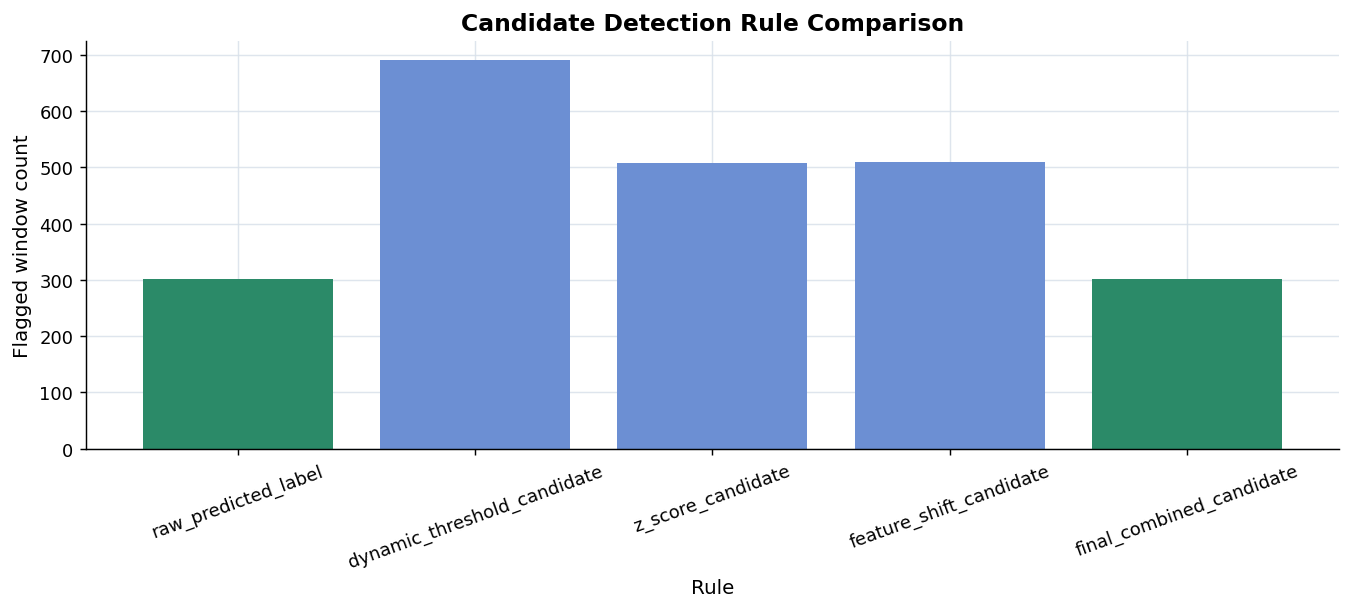

WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_candidate_rule_counts.png')

In [17]:
# This cell compares candidate-rule counts across exported flags and notebook-only proxy rules.
candidate_summary = pd.DataFrame(
    [
        {
            "rule": "raw_predicted_label",
            "count": int(viz_predictions["raw_predicted_flag"].sum()),
            "kind": "existing",
            "source": "predicted_label",
        },
        {
            "rule": "dynamic_threshold_candidate",
            "count": int(viz_predictions["dynamic_threshold_candidate_flag"].sum()),
            "kind": "analysis proxy",
            "source": "anomaly_score > rolling median + 3 * rolling std",
        },
        {
            "rule": "z_score_candidate",
            "count": int(viz_predictions["z_score_candidate_flag"].sum()),
            "kind": "analysis proxy",
            "source": "|score_z| >= 3",
        },
        {
            "rule": "feature_shift_candidate",
            "count": int(viz_predictions["feature_shift_candidate_flag"].sum()),
            "kind": "analysis proxy",
            "source": "|top_feature_error_z| >= 3",
        },
        {
            "rule": "final_combined_candidate",
            "count": int(viz_predictions["final_combined_candidate_flag"].sum()),
            "kind": "existing",
            "source": final_candidate_source,
        },
    ]
)
save_table(candidate_summary, "candidate_rule_summary.csv")
display(candidate_summary)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
colors = ["#6c8fd3" if kind == "analysis proxy" else "#2b8a68" for kind in candidate_summary["kind"]]
ax.bar(candidate_summary["rule"], candidate_summary["count"], color=colors)
ax.set_title("Candidate Detection Rule Comparison")
ax.set_xlabel("Rule")
ax.set_ylabel("Flagged window count")
ax.tick_params(axis="x", rotation=20)
style_axis(ax)

candidate_path = save_figure(fig, "eval_candidate_rule_counts.png")
plt.show()

candidate_path

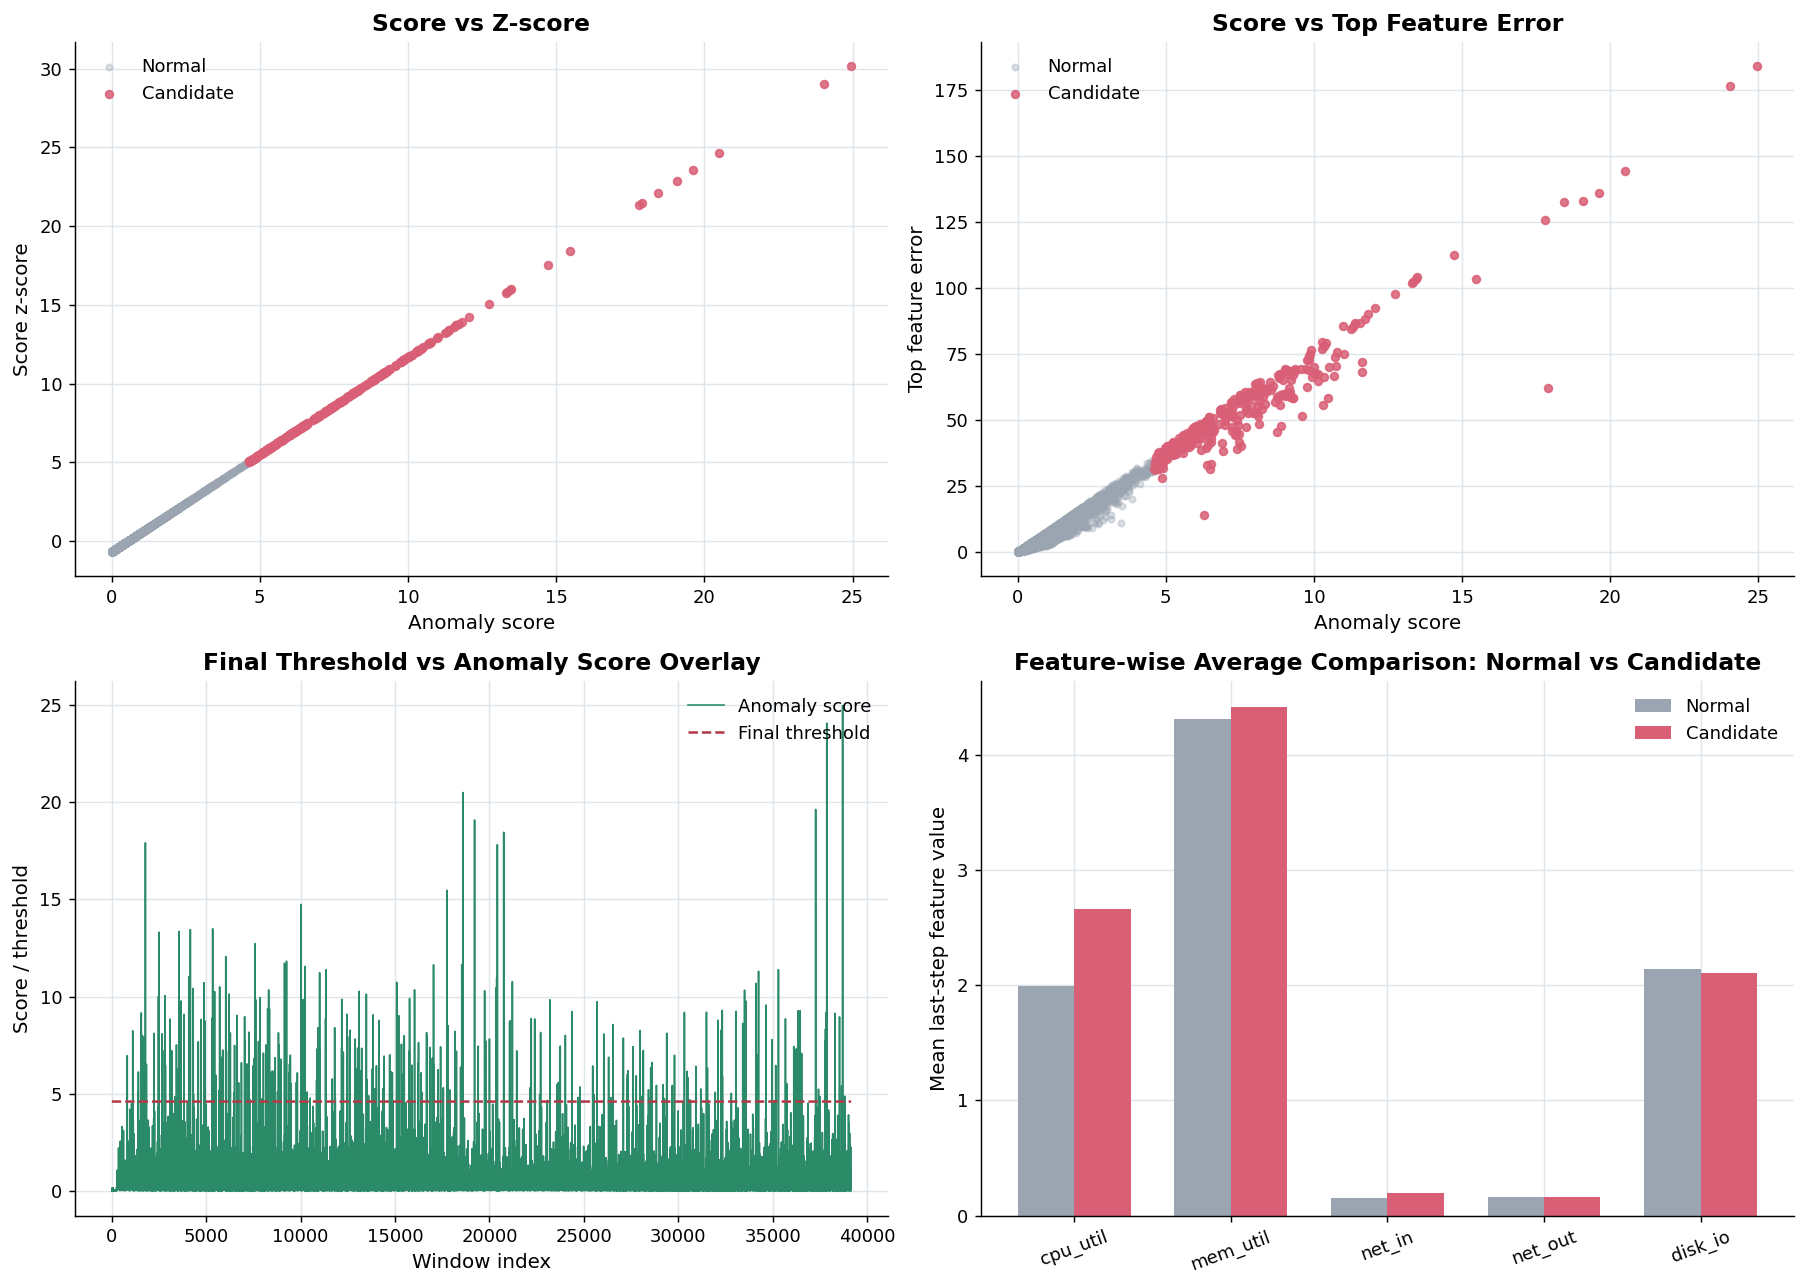

WindowsPath('C:/Users/kaspe/Desktop/Project/project/results/figures/eval_comparative_scatter_and_feature_means.png')

In [18]:
# This cell compares score relationships, final-threshold overlays, and normal-vs-candidate feature averages.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
candidate_mask = viz_predictions["final_combined_candidate_flag"].fillna(False).to_numpy()

axes[0, 0].scatter(
    viz_predictions.loc[~candidate_mask, "anomaly_score"],
    viz_predictions.loc[~candidate_mask, "score_z"],
    color=PALETTE["normal"],
    alpha=0.35,
    s=12,
    label="Normal",
)
axes[0, 0].scatter(
    viz_predictions.loc[candidate_mask, "anomaly_score"],
    viz_predictions.loc[candidate_mask, "score_z"],
    color=PALETTE["candidate"],
    alpha=0.85,
    s=18,
    label="Candidate",
)
axes[0, 0].set_title("Score vs Z-score")
axes[0, 0].set_xlabel("Anomaly score")
axes[0, 0].set_ylabel("Score z-score")
style_axis(axes[0, 0])
dedupe_legend(axes[0, 0], location="upper left")

if viz_predictions["top_feature_error"].notna().any():
    axes[0, 1].scatter(
        viz_predictions.loc[~candidate_mask, "anomaly_score"],
        viz_predictions.loc[~candidate_mask, "top_feature_error"],
        color=PALETTE["normal"],
        alpha=0.35,
        s=12,
        label="Normal",
    )
    axes[0, 1].scatter(
        viz_predictions.loc[candidate_mask, "anomaly_score"],
        viz_predictions.loc[candidate_mask, "top_feature_error"],
        color=PALETTE["candidate"],
        alpha=0.85,
        s=18,
        label="Candidate",
    )
    axes[0, 1].set_title("Score vs Top Feature Error")
    axes[0, 1].set_xlabel("Anomaly score")
    axes[0, 1].set_ylabel("Top feature error")
    style_axis(axes[0, 1])
    dedupe_legend(axes[0, 1], location="upper left")
else:
    safe_text_axis(axes[0, 1], "Score vs Top Feature Error", "top_feature_error is unavailable for this run.")

axes[1, 0].plot(viz_predictions["window_id"], viz_predictions["anomaly_score"], color=PALETTE["score"], linewidth=0.9, label="Anomaly score")
axes[1, 0].plot(viz_predictions["window_id"], viz_predictions["final_threshold"], color=PALETTE["threshold"], linestyle="--", linewidth=1.4, label="Final threshold")
axes[1, 0].set_title("Final Threshold vs Anomaly Score Overlay")
axes[1, 0].set_xlabel("Window index")
axes[1, 0].set_ylabel("Score / threshold")
style_axis(axes[1, 0])
dedupe_legend(axes[1, 0], location="upper right")

feature_average_comparison = pd.DataFrame()
if x_test is not None and selected_feature_names:
    feature_indices = [feature_columns.index(feature_name) for feature_name in selected_feature_names]
    last_step_values = np.asarray(x_test[:, -1, feature_indices], dtype=float)
    normal_mask = ~candidate_mask
    if normal_mask.any() and candidate_mask.any():
        feature_average_comparison = pd.DataFrame(
            {
                "feature": selected_feature_names,
                "normal_mean": last_step_values[normal_mask].mean(axis=0),
                "candidate_mean": last_step_values[candidate_mask].mean(axis=0),
            }
        )
        x_pos = np.arange(len(feature_average_comparison))
        width = 0.36
        axes[1, 1].bar(x_pos - width / 2, feature_average_comparison["normal_mean"], width=width, color=PALETTE["normal"], label="Normal")
        axes[1, 1].bar(x_pos + width / 2, feature_average_comparison["candidate_mean"], width=width, color=PALETTE["candidate"], label="Candidate")
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(feature_average_comparison["feature"], rotation=20)
        axes[1, 1].set_title("Feature-wise Average Comparison: Normal vs Candidate")
        axes[1, 1].set_ylabel("Mean last-step feature value")
        style_axis(axes[1, 1])
        dedupe_legend(axes[1, 1], location="upper right")
        save_table(feature_average_comparison, "feature_average_normal_vs_candidate.csv")
    else:
        safe_text_axis(axes[1, 1], "Feature-wise Average Comparison", "Normal/candidate groups were not both available.")
else:
    safe_text_axis(axes[1, 1], "Feature-wise Average Comparison", "X_test.npy or selected features were unavailable.")

comparative_path = save_figure(fig, "eval_comparative_scatter_and_feature_means.png")
plt.show()

comparative_path

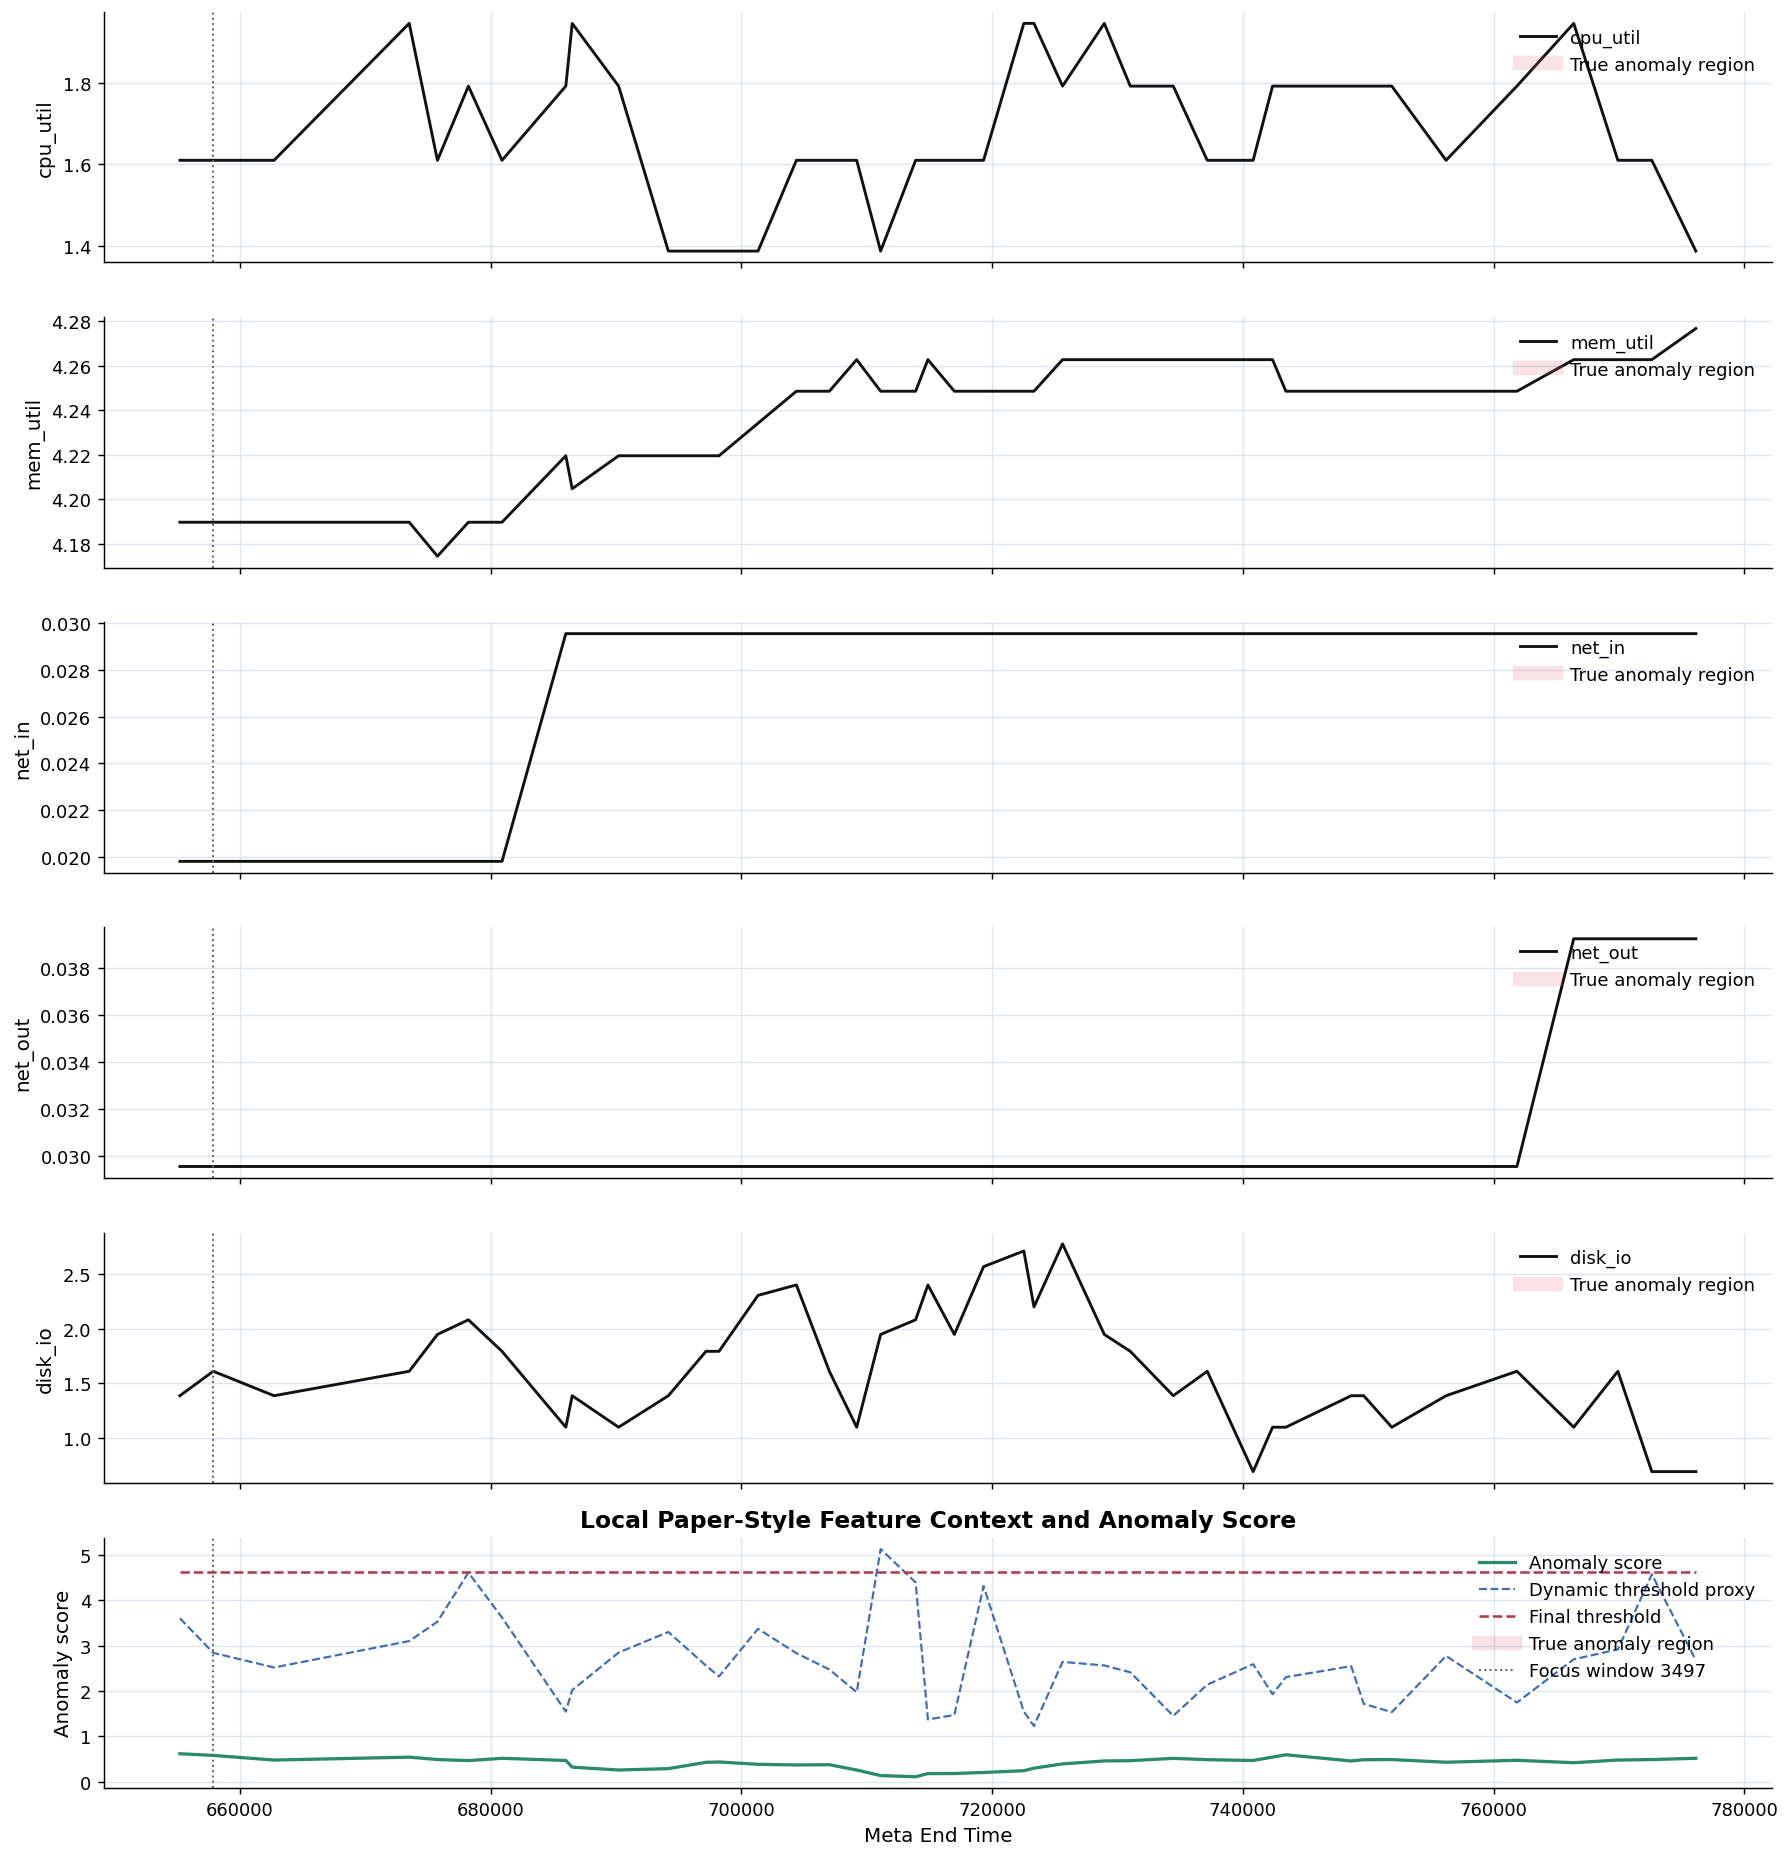

In [19]:
# This cell builds a local paper-style stacked view with selected feature traces in black and anomaly scores in green.
focus_candidates = viz_predictions[viz_predictions["candidate_region_flag"]].copy()
if focus_candidates.empty:
    focus_candidates = viz_predictions.sort_values("anomaly_score", ascending=False).head(1).copy()
focus_row = focus_candidates.sort_values("anomaly_score", ascending=False).iloc[0]
focus_window_id = int(focus_row["window_id"])

if "entity_id" in viz_predictions.columns and pd.notna(focus_row.get("entity_id")):
    local_frame = viz_predictions[viz_predictions["entity_id"] == focus_row["entity_id"]].copy()
    local_sort_col = "meta_end_time" if "meta_end_time" in local_frame.columns and local_frame["meta_end_time"].notna().any() else "window_id"
    local_frame = local_frame.sort_values(local_sort_col).reset_index(drop=True)
    local_focus_idx = int(local_frame.index[local_frame["window_id"].astype(int) == focus_window_id][0])
else:
    local_frame = viz_predictions.sort_values("window_id").reset_index(drop=True)
    local_sort_col = "window_id"
    local_focus_idx = int(local_frame.index[local_frame["window_id"].astype(int) == focus_window_id][0])

context_radius = 40
start_idx = max(0, local_focus_idx - context_radius)
end_idx = min(len(local_frame), local_focus_idx + context_radius + 1)
local_frame = local_frame.iloc[start_idx:end_idx].copy().reset_index(drop=True)
local_x = local_frame[local_sort_col].to_numpy()
focus_x = local_frame.loc[local_frame["window_id"].astype(int) == focus_window_id, local_sort_col].iloc[0]

if x_test is None or not selected_feature_names:
    note("Local feature-trace plotting was skipped because X_test.npy or the requested features were unavailable.")
else:
    available_feature_names = [feature_name for feature_name in selected_feature_names if feature_name in feature_columns]
    panel_count = len(available_feature_names) + 1
    fig, axes = plt.subplots(panel_count, 1, figsize=(14, 2.4 * panel_count), sharex=True)
    if panel_count == 1:
        axes = [axes]

    for axis, feature_name in zip(axes[:-1], available_feature_names):
        feature_idx = feature_columns.index(feature_name)
        feature_trace = np.asarray(
            x_test[local_frame["window_id"].astype(int).to_numpy(), -1, feature_idx],
            dtype=float,
        )
        axis.plot(local_x, feature_trace, color=PALETTE["feature"], linewidth=1.6, label=feature_name)
        add_region_overlay(axis, local_frame, local_sort_col, "candidate_region_flag", candidate_region_label, PALETTE["candidate"], alpha=0.12)
        axis.axvline(focus_x, color="#666666", linestyle=":", linewidth=1.1)
        axis.set_ylabel(feature_name)
        style_axis(axis)
        dedupe_legend(axis, location="upper right")

    score_axis = axes[-1]
    score_axis.plot(local_x, local_frame["anomaly_score"], color=PALETTE["score"], linewidth=1.8, label="Anomaly score")
    if "dynamic_threshold_proxy" in local_frame.columns:
        score_axis.plot(local_x, local_frame["dynamic_threshold_proxy"], color=PALETTE["dynamic"], linestyle="--", linewidth=1.2, label="Dynamic threshold proxy")
    if "final_threshold" in local_frame.columns:
        score_axis.plot(local_x, local_frame["final_threshold"], color=PALETTE["threshold"], linestyle="--", linewidth=1.4, label="Final threshold")
    if "raw_predicted_flag" in local_frame.columns and local_frame["raw_predicted_flag"].any():
        score_axis.scatter(
            local_frame.loc[local_frame["raw_predicted_flag"], local_sort_col],
            local_frame.loc[local_frame["raw_predicted_flag"], "anomaly_score"],
            color=PALETTE["marker"],
            marker="D",
            s=26,
            zorder=5,
            label="Predicted anomaly",
        )
    add_region_overlay(score_axis, local_frame, local_sort_col, "candidate_region_flag", candidate_region_label, PALETTE["candidate"], alpha=0.12)
    score_axis.axvline(focus_x, color="#666666", linestyle=":", linewidth=1.1, label=f"Focus window {focus_window_id}")
    score_axis.set_title("Local Paper-Style Feature Context and Anomaly Score")
    score_axis.set_xlabel(local_sort_col.replace("_", " ").title())
    score_axis.set_ylabel("Anomaly score")
    style_axis(score_axis)
    dedupe_legend(score_axis, location="upper right")

    timeseries_path = save_figure(fig, "eval_local_timeseries_feature_score_stack.png")
    plt.show()
    timeseries_path

In [20]:
# This cell lists the saved figure and table artifacts produced by the analysis section.
artifact_rows = []
for filename, path in saved_figures.items():
    artifact_rows.append({"type": "figure", "filename": filename, "path": path})
for filename, path in saved_tables.items():
    artifact_rows.append({"type": "table", "filename": filename, "path": path})
artifact_df = pd.DataFrame(artifact_rows).sort_values(["type", "filename"]).reset_index(drop=True)
display(artifact_df)
artifact_df

,type,filename,path
0,figure,eval_candidate_rule_counts.png,C:\Users\kaspe\Desktop\Project\project\results...
1,figure,eval_comparative_scatter_and_feature_means.png,C:\Users\kaspe\Desktop\Project\project\results...
2,figure,eval_distribution_histograms.png,C:\Users\kaspe\Desktop\Project\project\results...
3,figure,eval_feature_importance_comparison.png,C:\Users\kaspe\Desktop\Project\project\results...
4,figure,eval_local_timeseries_feature_score_stack.png,C:\Users\kaspe\Desktop\Project\project\results...
5,figure,eval_score_boxplots.png,C:\Users\kaspe\Desktop\Project\project\results...
6,figure,eval_threshold_comparison.png,C:\Users\kaspe\Desktop\Project\project\results...
7,figure,eval_top_window_ranking.png,C:\Users\kaspe\Desktop\Project\project\results...
8,table,analysis_signal_notes.csv,C:\Users\kaspe\Desktop\Project\project\results...
9,table,candidate_rule_summary.csv,C:\Users\kaspe\Desktop\Project\project\results...


,type,filename,path
0,figure,eval_candidate_rule_counts.png,C:\Users\kaspe\Desktop\Project\project\results...
1,figure,eval_comparative_scatter_and_feature_means.png,C:\Users\kaspe\Desktop\Project\project\results...
2,figure,eval_distribution_histograms.png,C:\Users\kaspe\Desktop\Project\project\results...
3,figure,eval_feature_importance_comparison.png,C:\Users\kaspe\Desktop\Project\project\results...
4,figure,eval_local_timeseries_feature_score_stack.png,C:\Users\kaspe\Desktop\Project\project\results...
5,figure,eval_score_boxplots.png,C:\Users\kaspe\Desktop\Project\project\results...
6,figure,eval_threshold_comparison.png,C:\Users\kaspe\Desktop\Project\project\results...
7,figure,eval_top_window_ranking.png,C:\Users\kaspe\Desktop\Project\project\results...
8,table,analysis_signal_notes.csv,C:\Users\kaspe\Desktop\Project\project\results...
9,table,candidate_rule_summary.csv,C:\Users\kaspe\Desktop\Project\project\results...
